# Assignment 2: Face Detection and Recognition
#### Kinyua Seaman
**Objective:**
1. Implement a face detection algorithm using Haar cascades in OpenCV.
2. Use PyTorch to train a facial recognition model.

**Dataset:** We are using the local `YouTube Faces with Facial Keypoints` dataset provided in the `data/archive` folder. The dataset consists of `.npz` files containing sequences of video frames for various celebrities.

In [3]:
import os
import glob
import cv2
import torch
import torchvision
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from sklearn.model_selection import train_test_split

print("PyTorch Version:", torch.__version__)
print("OpenCV Version:", cv2.__version__)

PyTorch Version: 2.11.0+cu130
OpenCV Version: 4.13.0


## 1. Load the YouTube Faces Dataset & Apply Haar Cascades
We will iterate through the `.npz` files, extract frames, and use OpenCV's Haar cascades to detect and crop the faces.

Found 2194 video sequences.
Selected top 10 identity classes for training: ['Alison_Lohman', 'Kevin_Spacey', 'Lauren_Hutton', 'Robert_F_Kennedy_Jr', 'Amanda_Beard', 'Andrew_Bernard', 'Barbara_Brezigar', 'Daniel_Kurtzer', 'Elizabeth_Berkeley', 'Fred_Eckhard']
Processing .npz files with Haar Cascades...
Successfully extracted 302 faces from the top 10 classes.


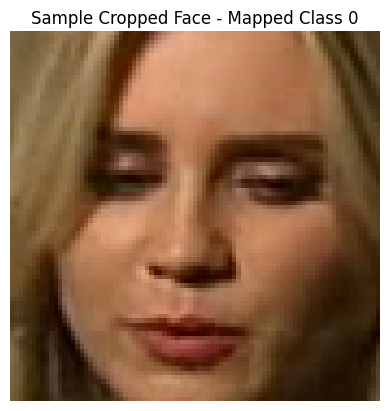

In [4]:
archive_dir = './data/archive'
npz_files = glob.glob(os.path.join(archive_dir, '**/*.npz'), recursive=True)
print(f"Found {len(npz_files)} video sequences.")

# Extract identities from filenames (e.g., 'AJ_Cook_0.npz' -> 'AJ_Cook')
identities = ["_".join(os.path.basename(f).split('_')[:-1]) for f in npz_files]
counts = Counter(identities)
top_classes = [label for label, _ in counts.most_common(10)]
print(f"Selected top 10 identity classes for training: {top_classes}")

# Load OpenCV Haar cascade
cascade_path = cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
face_cascade = cv2.CascadeClassifier(cascade_path)

cropped_faces = []
target_labels = []

print("Processing .npz files with Haar Cascades...")
for f in npz_files:
    identity = "_".join(os.path.basename(f).split('_')[:-1])
    if identity not in top_classes:
        continue
        
    try:
        data = np.load(f)
        if 'colorImages' not in data.files:
            continue
            
        # Shape is (Height, Width, 3, Frames)
        images = data['colorImages']
        num_frames = images.shape[3]
        
        # Extract up to 5 evenly spaced frames per video sequence
        step = max(1, num_frames // 5)
        
        for i in range(0, num_frames, step):
            img_np = images[:, :, :, i]
            
            # Detect faces (convert to grayscale first)
            gray = cv2.cvtColor(img_np, cv2.COLOR_RGB2GRAY)
            faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=3, minSize=(20, 20))
            
            if len(faces) > 0:
                largest_face = max(faces, key=lambda rect: rect[2] * rect[3])
                x, y, w, h = largest_face
                face_crop = img_np[y:y+h, x:x+w]
                
                cropped_faces.append(face_crop)
                target_labels.append(top_classes.index(identity))
    except Exception as e:
        print(f"Error processing {f}: {e}")

print(f"Successfully extracted {len(cropped_faces)} faces from the top 10 classes.")

# Visualize a detection result
if len(cropped_faces) > 0:
    plt.imshow(cropped_faces[0])
    plt.title(f"Sample Cropped Face - Mapped Class {target_labels[0]}")
    plt.axis('off')
    plt.show()

## 2. PyTorch Data Preparation

In [5]:
class FaceDataset(Dataset):
    def __init__(self, faces, labels, transform=None):
        self.faces = faces
        self.labels = labels
        self.transform = transform
        
    def __len__(self):
        return len(self.faces)
        
    def __getitem__(self, idx):
        face = self.faces[idx]
        label = self.labels[idx]
        
        if self.transform:
            face = self.transform(face)
            
        return face, torch.tensor(label, dtype=torch.long)

# Transform: Resize to 128x128, convert to Tensor, and normalize [-1, 1]
transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# Ensure all cropped faces are in RGB format for the transform
rgb_faces = [cv2.cvtColor(face, cv2.COLOR_GRAY2RGB) if len(face.shape)==2 else face for face in cropped_faces]

# Train-test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(rgb_faces, target_labels, test_size=0.2, random_state=42)

train_dataset = FaceDataset(X_train, y_train, transform=transform)
test_dataset = FaceDataset(X_test, y_test, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"Training samples: {len(train_dataset)}, Testing samples: {len(test_dataset)}")

Training samples: 241, Testing samples: 61


## 3. PyTorch Model Definition

In [6]:
class SimpleFaceCNN(nn.Module):
    def __init__(self, num_classes):
        super(SimpleFaceCNN, self).__init__()
        # Input: 3 x 128 x 128
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        # After pool: 32 x 64 x 64
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        # After pool: 64 x 32 x 32
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        # After pool: 128 x 16 x 16
        
        self.fc1 = nn.Linear(128 * 16 * 16, 512)
        self.fc2 = nn.Linear(512, num_classes)
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = x.view(-1, 128 * 16 * 16) # Flatten
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

model = SimpleFaceCNN(num_classes=10)
print(model)

SimpleFaceCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=32768, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=10, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
)


## 4. Training the PyTorch Model

Training on device: cpu
Epoch [1/15], Loss: 2.3258
Epoch [2/15], Loss: 1.6450
Epoch [3/15], Loss: 1.0724
Epoch [4/15], Loss: 0.7208
Epoch [5/15], Loss: 0.4633
Epoch [6/15], Loss: 0.5898
Epoch [7/15], Loss: 0.2900
Epoch [8/15], Loss: 0.1940
Epoch [9/15], Loss: 0.1609
Epoch [10/15], Loss: 0.0996
Epoch [11/15], Loss: 0.1683
Epoch [12/15], Loss: 0.0460
Epoch [13/15], Loss: 0.0745
Epoch [14/15], Loss: 0.0766
Epoch [15/15], Loss: 0.0592


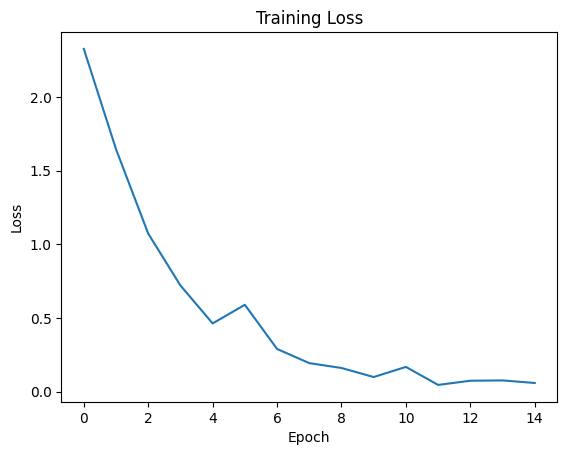

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on device: {device}")
model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 15
train_losses = []

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        
    avg_loss = running_loss / len(train_loader)
    train_losses.append(avg_loss)
    print(f"Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.4f}")

plt.plot(train_losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

## 5. Model Evaluation

In [8]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f"Test Accuracy on top 10 identities: {accuracy:.2f}%")

Test Accuracy on top 10 identities: 93.44%
